# exp-gs-002-11 — soft-gated KIRC↔KIPAN specialist LR

## 실험 목적

08 최종 26-class LR의 KIRC/KIPAN 확률합은 유지하고, 그 내부 비율만 KIRC/KIPAN binary specialist LR로 보정한다. hard 2차 분류나 top-k threshold는 사용하지 않는다.

- primary: 08 최종 전처리·26-class LR 전체
- specialist: 같은 fold-train에서 KIRC/KIPAN 행만 사용한 binary LR
- soft gate: `weight = ALPHA × (p(KIRC)+p(KIPAN))`, `ALPHA=0.30` 고정
- 다른 24개 클래스 확률과 KIRC/KIPAN 확률합은 그대로 유지
- seeds `42/2024/777`, Stratified 5-fold, fold-train only
- OOF 실행은 train만 읽고 평가 데이터 파일을 읽지 않음

판정은 3-seed Macro F1 paired delta가 모두 양수이고, KIRC/KIPAN F1 또는 양방향 혼동이 악화되지 않을 때만 채택 후보로 한다.


In [1]:
from pathlib import Path
import json
import subprocess
import sys

import matplotlib.pyplot as plt
import pandas as pd
from tqdm.auto import tqdm

def find_eda_dir() -> Path:
    for path in (Path.cwd(), *Path.cwd().parents):
        if (path / 'common' / 'exp-gs-002-memory-safe.py').exists():
            return path
        candidate = path / 'experiments' / 'gs' / 'notebooks' / 'eda_pre_002'
        if (candidate / 'common' / 'exp-gs-002-memory-safe.py').exists():
            return candidate
    raise FileNotFoundError('eda_pre_002/common 실행기를 찾지 못했습니다.')

EDA_DIR = find_eda_dir()
RUNNER = EDA_DIR / 'common' / 'exp-gs-002-memory-safe.py'
RESULT_DIR = EDA_DIR / 'result'
RESULT_DIR.mkdir(parents=True, exist_ok=True)

RUN_ID = 'exp-gs-002-11'
CANDIDATE = 'H-AS-LR-exact-confusion-pairs-Apair-log1p'
LEFT_CLASS, RIGHT_CLASS = 'KIRC', 'KIPAN'
ALPHA = 0.30
SEEDS = (42, 2024, 777)
RUN_EXPERIMENT = True
OOF_TRAIN_ONLY = True

print({'runner': RUNNER, 'candidate': CANDIDATE, 'pair': (LEFT_CLASS, RIGHT_CLASS), 'alpha': ALPHA, 'seeds': SEEDS, 'oof_train_only': OOF_TRAIN_ONLY})


{'runner': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/eda_pre_002/common/exp-gs-002-memory-safe.py'), 'candidate': 'H-AS-LR-exact-confusion-pairs-Apair-log1p', 'pair': ('KIRC', 'KIPAN'), 'alpha': 0.3, 'seeds': (42, 2024, 777), 'oof_train_only': True}


/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. 3-seed fold-safe specialist OOF 실행

각 outer fold에서 primary와 specialist를 모두 fold-train만으로 fit한다. validation 확률은 해당 fold의 두 모델로만 생성한다.


In [2]:
if RUN_EXPERIMENT:
    for seed in tqdm(SEEDS, desc='11 | soft-gated KIRC-KIPAN specialist | OOF', unit='seed'):
        command = [
            sys.executable, str(RUNNER),
            '--run-id', RUN_ID,
            '--candidate', CANDIDATE,
            '--seed', str(seed),
            '--soft-specialist',
            '--specialist-left', LEFT_CLASS,
            '--specialist-right', RIGHT_CLASS,
            '--specialist-alpha', str(ALPHA),
        ]
        subprocess.run(command, check=True)
else:
    print('RUN_EXPERIMENT=False: 기존 결과 파일만 집계합니다.')


row-local mutation cache: 100%|██████████| 4384/4384 [00:11<00:00, 395.48it/s]eed/s]
H-AS-LR-exact-confusion-pairs-Apair-log1p | soft specialist | seed 42: 100%|██████████| 5/5 [03:20<00:00, 40.05s/it]


{
  "experiment_id": "H-AS-LR-exact-confusion-pairs-Apair-log1p",
  "model": "logistic",
  "seed": 42,
  "specialist_left": "KIRC",
  "specialist_right": "KIPAN",
  "specialist_alpha": 0.3,
  "primary_oof_macro_f1": 0.47814168846488037,
  "soft_specialist_oof_macro_f1": 0.47814168846488037,
  "delta_oof_macro_f1": 0.0,
  "primary_oof_accuracy": 0.45879696823093047,
  "soft_specialist_oof_accuracy": 0.45879696823093047,
  "fold_soft_specialist_macro_f1_mean": 0.47829869725520846,
  "fold_soft_specialist_macro_f1_std": 0.008298637176475701,
  "feature_count_mean": 8175.2,
  "specialist_train_rows_mean": 679.2,
  "runtime_seconds": 200.40321162500186,
  "primary_convergence_warning_count": 0,
  "specialist_convergence_warning_count": 0,
  "convergence_warning_count": 0,
  "leakage_check": true,
  "nan_as_mutation_count": 0
}


row-local mutation cache: 100%|██████████| 4384/4384 [00:10<00:00, 403.87it/s], 223.94s/seed]
H-AS-LR-exact-confusion-pairs-Apair-log1p | soft specialist | seed 2024: 100%|██████████| 5/5 [03:17<00:00, 39.59s/it]


{
  "experiment_id": "H-AS-LR-exact-confusion-pairs-Apair-log1p",
  "model": "logistic",
  "seed": 2024,
  "specialist_left": "KIRC",
  "specialist_right": "KIPAN",
  "specialist_alpha": 0.3,
  "primary_oof_macro_f1": 0.4762175133106753,
  "soft_specialist_oof_macro_f1": 0.47625716162312615,
  "delta_oof_macro_f1": 3.964831245084621e-05,
  "primary_oof_accuracy": 0.4594420254797613,
  "soft_specialist_oof_accuracy": 0.4594420254797613,
  "fold_soft_specialist_macro_f1_mean": 0.47458298747979893,
  "fold_soft_specialist_macro_f1_std": 0.015875498644683385,
  "feature_count_mean": 8175.0,
  "specialist_train_rows_mean": 679.2,
  "runtime_seconds": 198.0972458749893,
  "primary_convergence_warning_count": 0,
  "specialist_convergence_warning_count": 0,
  "convergence_warning_count": 0,
  "leakage_check": true,
  "nan_as_mutation_count": 0
}


row-local mutation cache: 100%|██████████| 4384/4384 [00:11<00:00, 397.80it/s], 222.83s/seed]
H-AS-LR-exact-confusion-pairs-Apair-log1p | soft specialist | seed 777: 100%|██████████| 5/5 [03:09<00:00, 37.90s/it]


{
  "experiment_id": "H-AS-LR-exact-confusion-pairs-Apair-log1p",
  "model": "logistic",
  "seed": 777,
  "specialist_left": "KIRC",
  "specialist_right": "KIPAN",
  "specialist_alpha": 0.3,
  "primary_oof_macro_f1": 0.481145738774279,
  "soft_specialist_oof_macro_f1": 0.4813300625001836,
  "delta_oof_macro_f1": 0.00018432372590460044,
  "primary_oof_accuracy": 0.4613771972262538,
  "soft_specialist_oof_accuracy": 0.46169972585066926,
  "fold_soft_specialist_macro_f1_mean": 0.4804204957620404,
  "fold_soft_specialist_macro_f1_std": 0.01694576994029513,
  "feature_count_mean": 8170.4,
  "specialist_train_rows_mean": 679.2,
  "runtime_seconds": 189.6681124579918,
  "primary_convergence_warning_count": 0,
  "specialist_convergence_warning_count": 0,
  "convergence_warning_count": 0,
  "leakage_check": true,
  "nan_as_mutation_count": 0
}


11 | soft-gated KIRC-KIPAN specialist | OOF: 100%|██████████| 3/3 [10:59<00:00, 219.82s/seed]


## 2. OOF·pair confusion·감사 조건 집계

primary와 soft-specialist의 paired delta, KIRC/KIPAN 클래스 F1, 양방향 혼동 수, 수렴·누수·NaN 검증을 함께 기록한다.


In [3]:
def result_path(seed: int, suffix: str) -> Path:
    stem = f'{RUN_ID}_{CANDIDATE}_soft-specialist_seed{seed}'
    return RESULT_DIR / f'{stem}_{suffix}.csv'

oof_paths = [result_path(seed, 'oof') for seed in SEEDS]
missing = [path for path in oof_paths if not path.exists()]
if missing:
    raise FileNotFoundError('아직 실행되지 않은 결과 파일이 있습니다:\n' + '\n'.join(map(str, missing)))

per_seed = pd.concat([pd.read_csv(path) for path in oof_paths], ignore_index=True).sort_values('seed')
assert set(per_seed['seed']) == set(SEEDS)
assert per_seed['leakage_check'].all()
assert per_seed['nan_as_mutation_count'].eq(0).all()
assert per_seed['specialist_alpha'].eq(ALPHA).all()

class_seed = pd.concat([pd.read_csv(result_path(seed, 'class_f1')).assign(seed=seed) for seed in SEEDS], ignore_index=True)
pair_seed = pd.concat([pd.read_csv(result_path(seed, 'pair_confusion')).assign(seed=seed) for seed in SEEDS], ignore_index=True)
class_summary = (class_seed.groupby(['variant', 'class'], as_index=False)
    .agg(class_f1_mean=('f1-score', 'mean'), class_f1_std=('f1-score', 'std'), support=('support', 'first'))
)
pair_summary = (pair_seed.groupby(['variant', 'true_class', 'predicted_class'], as_index=False)
    .agg(confusion_count_mean=('count', 'mean'), confusion_count_std=('count', 'std'))
)

mean_delta = per_seed['delta_oof_macro_f1'].mean()
all_positive = bool(per_seed['delta_oof_macro_f1'].gt(0).all())
pair_f1 = class_summary[class_summary['class'].isin((LEFT_CLASS, RIGHT_CLASS))].pivot(index='class', columns='variant', values='class_f1_mean')
pair_f1_not_worse = bool((pair_f1['soft_specialist'] >= pair_f1['primary']).all())
status = '채택 후보' if all_positive and pair_f1_not_worse else '미검출/기각'

summary = pd.DataFrame([{
    'experiment_id': RUN_ID, 'candidate': CANDIDATE, 'pair': f'{LEFT_CLASS}↔{RIGHT_CLASS}', 'alpha': ALPHA,
    'seed_count': len(SEEDS), 'primary_oof_macro_f1_mean': per_seed['primary_oof_macro_f1'].mean(), 'primary_oof_macro_f1_std': per_seed['primary_oof_macro_f1'].std(),
    'soft_specialist_oof_macro_f1_mean': per_seed['soft_specialist_oof_macro_f1'].mean(), 'soft_specialist_oof_macro_f1_std': per_seed['soft_specialist_oof_macro_f1'].std(),
    'paired_delta_mean': mean_delta, 'paired_delta_std': per_seed['delta_oof_macro_f1'].std(), 'all_seed_delta_positive': all_positive,
    'pair_f1_not_worse': pair_f1_not_worse, 'feature_count_mean': per_seed['feature_count_mean'].mean(),
    'runtime_seconds_mean': per_seed['runtime_seconds'].mean(), 'convergence_warning_count': per_seed['convergence_warning_count'].sum(),
    'leakage_check': bool(per_seed['leakage_check'].all()), 'nan_as_mutation_count': int(per_seed['nan_as_mutation_count'].sum()), 'status': status,
}])

per_seed.to_csv(RESULT_DIR / 'exp-gs-002-11_per_seed.csv', index=False)
class_summary.to_csv(RESULT_DIR / 'exp-gs-002-11_class_f1_summary.csv', index=False)
pair_summary.to_csv(RESULT_DIR / 'exp-gs-002-11_pair_confusion_summary.csv', index=False)
summary.to_csv(RESULT_DIR / 'exp-gs-002-11_summary.csv', index=False)
with (RESULT_DIR / 'exp-gs-002-11_audit.json').open('w', encoding='utf-8') as file:
    json.dump({'oof_train_only': OOF_TRAIN_ONLY, 'alpha': ALPHA, 'all_seed_delta_positive': all_positive, 'pair_f1_not_worse': pair_f1_not_worse, 'status': status}, file, ensure_ascii=False, indent=2)

display(per_seed)
display(pair_f1.reset_index())
display(pair_summary)
display(summary)


,experiment_id,model,seed,specialist_left,specialist_right,specialist_alpha,primary_oof_macro_f1,soft_specialist_oof_macro_f1,delta_oof_macro_f1,primary_oof_accuracy,...,fold_soft_specialist_macro_f1_mean,fold_soft_specialist_macro_f1_std,feature_count_mean,specialist_train_rows_mean,runtime_seconds,primary_convergence_warning_count,specialist_convergence_warning_count,convergence_warning_count,leakage_check,nan_as_mutation_count
0,H-AS-LR-exact-confusion-pairs-Apair-log1p,logistic,42,KIRC,KIPAN,0.3,0.478142,0.478142,0.000000,0.458797,...,0.478299,0.008299,8175.2,679.2,200.403212,0,0,0,True,0
2,H-AS-LR-exact-confusion-pairs-Apair-log1p,logistic,777,KIRC,KIPAN,0.3,0.481146,0.481330,0.000184,0.461377,...,0.480420,0.016946,8170.4,679.2,189.668112,0,0,0,True,0
1,H-AS-LR-exact-confusion-pairs-Apair-log1p,logistic,2024,KIRC,KIPAN,0.3,0.476218,0.476257,0.000040,0.459442,...,0.474583,0.015875,8175.0,679.2,198.097246,0,0,0,True,0


variant,class,primary,soft_specialist
0,KIPAN,0.235221,0.235896
1,KIRC,0.246534,0.246657


,variant,true_class,predicted_class,confusion_count_mean,confusion_count_std
0,primary,KIPAN,KIRC,232.333333,4.163332
1,primary,KIRC,KIPAN,151.000000,6.082763
2,soft_specialist,KIPAN,KIRC,231.666667,5.033223
3,soft_specialist,KIRC,KIPAN,151.000000,6.082763


,experiment_id,candidate,pair,alpha,seed_count,primary_oof_macro_f1_mean,primary_oof_macro_f1_std,soft_specialist_oof_macro_f1_mean,soft_specialist_oof_macro_f1_std,paired_delta_mean,paired_delta_std,all_seed_delta_positive,pair_f1_not_worse,feature_count_mean,runtime_seconds_mean,convergence_warning_count,leakage_check,nan_as_mutation_count,status
0,exp-gs-002-11,H-AS-LR-exact-confusion-pairs-Apair-log1p,KIRC↔KIPAN,0.3,3,0.478502,0.002484,0.478576,0.002564,0.000075,0.000097,False,True,8173.533333,196.05619,0,True,0,미검출/기각


## 3. 시각화

seed별 Macro F1 변화와 KIRC→KIPAN, KIPAN→KIRC 혼동 수 변화를 확인한다.


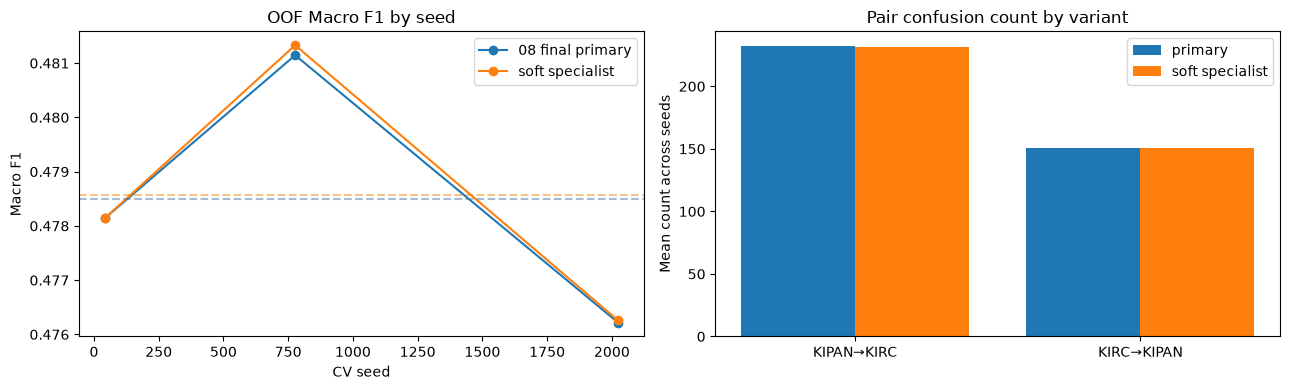

/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/eda_pre_002/result/exp-gs-002-11_specialist_summary.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(per_seed['seed'], per_seed['primary_oof_macro_f1'], marker='o', label='08 final primary')
axes[0].plot(per_seed['seed'], per_seed['soft_specialist_oof_macro_f1'], marker='o', label='soft specialist')
axes[0].axhline(per_seed['primary_oof_macro_f1'].mean(), color='#4C78A8', linestyle='--', alpha=0.5)
axes[0].axhline(per_seed['soft_specialist_oof_macro_f1'].mean(), color='#F58518', linestyle='--', alpha=0.5)
axes[0].set_title('OOF Macro F1 by seed')
axes[0].set_xlabel('CV seed')
axes[0].set_ylabel('Macro F1')
axes[0].legend()
pivot_confusion = pair_summary.pivot(index=['true_class', 'predicted_class'], columns='variant', values='confusion_count_mean').reset_index()
x = range(len(pivot_confusion))
axes[1].bar([value - 0.2 for value in x], pivot_confusion['primary'], width=0.4, label='primary')
axes[1].bar([value + 0.2 for value in x], pivot_confusion['soft_specialist'], width=0.4, label='soft specialist')
axes[1].set_xticks(list(x), [f'{row.true_class}→{row.predicted_class}' for row in pivot_confusion.itertuples()])
axes[1].set_title('Pair confusion count by variant')
axes[1].set_ylabel('Mean count across seeds')
axes[1].legend()
fig.tight_layout()
plot_path = RESULT_DIR / 'exp-gs-002-11_specialist_summary.png'
fig.savefig(plot_path, dpi=160, bbox_inches='tight')
plt.show()
print(plot_path)
